# AfyaFlow

### Hospital-Wide Outpatient Demand & Resource Allocation Prototype

### AIC Kijabe Hospital
AIC Kijabe Hospital is located in Kijabe, Kiambu County, Kenya, started as Kijabe Station was first established by missionaries from AIM as an outpost in 1903 upgrading first hospital at Kijabe, Theodora Hospital, was established in 1915. This served the medical needs of the area until the present complex was begun.
Today, Kijabe Hospital is a non-profit, 363-bed hospital owned and operated by AIC of Kenya as part of a network of four hospitals and 45 dispensaries. It has 1,078 employees as of Jul 26 and strives to balance Kenyan and missionary consultants. The hospital has daily average visits of about 355 and monthly average vistis of 10,677 patients a broad range of inpatient and outpatient curative services to people from the surrounding farming communities.

### Project Overview

The model uses historical outpatient records to identify patterns in patient attendance and predict periods of high demand across hospital departments. These insights will support  staff in providing medical services and efficient resource allocation, helping the hospital reduce congestion and improve patient flow.


# Business Understanding

### Problem Definition

Kijabe experiences variation in patient volumes across days and departments, making it difficult to anticipate where demand will occur and whether available capacity will be sufficient. During high-demand periods, patient volumes may exceed the available clinical capacity, contributing to congestion, longer waiting times and increased pressure on staff and resources. For instance patient volumes vary by day where weekdays have higher visits than weekends with with an average of 35 - 69 vists per hour during peak working hours potentially contribution to longer wait times for patients

### Business Objectives

AfyaFlow aims to use Kijabe Hospital's historical outpatient data and relevant internal operational factors to understand and predict patient demand across the hospital. The goal is to identify where and when high patient volumes are likely to occur and provide insights that can support proactive planning and decision-making.

The project aims: 
- To predict outpatient demand in the hospital and time periods.
- To identify departments, days, and time periods that are most likely to experience high patient volumes and congestion.
- To analyse historical patterns and factors that influence changes in outpatient demand.
- To support decisions on how available clinicians and resources can be allocated based on predicted demand.
- To provide hospital-wide insights to support capacity planning and improve patient flow.

### Research Questions
* How can historical patient data and predictive analytics be used to anticipate patient demand and support capacity planning to reduce congestion at Kijabe Hospital?
* What temporal patterns influence patient demand at Kijabe Hospital?
* Can patient-level historical patterns identify recurring patients and help explain predictable components of hospital demand?
* Can a scenario-based simulation help hospital decision-makers evaluate the potential effect of resource allocation decisions on congestion?
  
### Key Stakeholders

* Hospital Management: Requires hospital-wide demand insights to support capacity, staffing, and resource planning.
* Department Managers: Need demand forecasts to prepare for expected changes in patient volumes.
* Clinicians and Nurses: Benefit from better planning and distribution of workload and available clinical capacity.
* Patients: Benefit from improved patient flow, reduced waiting times, and more efficient service delivery.

### Data Science Tasks

The project will analyse Kijabe Hospital's historical outpatient data to identify patterns in patient attendance across departments and different time periods. Predictive models will then be developed to forecast future outpatient demand and identify periods of potentially high patient volumes. These predictions will be translated into decision-support insights to help the hospital plan staffing and resources according to anticipated demand.

# Data Understanding

### Data Overview

Opd_data.xlsx comes from Kijabe Hospital's outpatient records system. It has 306,306 rows and 6 columns, covering 1 June 2024 to 19 August 2026 (about 26.5 months, with the last month not fully complete). This is the only data we have for the project so far there's no separate data on staff numbers or bed availability yet.

#### Column Description
* PatientNumber - Represents the unique hospital identifier assigned to each patient. It is used to link repeat visits to the same individual and is not a row identifier, since one patient can appear many times.
* RegistrationDate - Represents the date and time at which the patient was registered into a service queue. This is the main temporal field in the dataset and provides the year, month, day of week and hour used for demand analysis.
* Gender - Represents the gender of the patient, recorded as Male or Female.
* Age - Represents the age of the patient at the time of registration, recorded as text with a unit attached, for example "38 Yr(s)", "6 Mth(s)", "3 Week(s)" or "5 Days(s)".
* QueuedTo - Represents the department or clinic the patient was queued to, for example General OPD, MCH, Chronic Care Clinic, Oncology, Renal or Dental. This is the main department field and the unit at which demand is analysed.
* ConsultDescription - Represents the type or purpose of the consultation the patient was booked for, for example General Outpatient Care, Admission, Chemotherapy, MCH Clinic or ENT Return Visit. It gives a finer-
grained view of service type within a department, and also distinguishes new visits from return visits.


In [6]:
# Library Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


#Load Dataset
data =  pd.read_excel("Opd_data.xlsx")  

In [7]:
#basic understanding of the datset
print(f'The dataset has {data.shape[0]} rows and {data.shape[1]} columns\n')
print('Dataset Columns:\n',data.columns)
print('\n Dataset Data types:\n',data.dtypes)

The dataset has 306306 rows and 6 columns

Dataset Columns:
 Index(['PatientNumber', 'RegistrationDate', 'Gender', 'Age', 'QueuedTo',
       'ConsultDescription'],
      dtype='object')

 Dataset Data types:
 PatientNumber                 object
RegistrationDate      datetime64[ns]
Gender                        object
Age                           object
QueuedTo                      object
ConsultDescription            object
dtype: object


Observation: The dataset has 6 columns. All the data types are correct apart fromthe age columns that should be numeric

In [8]:
#Checking Info of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306306 entries, 0 to 306305
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   PatientNumber       306306 non-null  object        
 1   RegistrationDate    306306 non-null  datetime64[ns]
 2   Gender              306291 non-null  object        
 3   Age                 305735 non-null  object        
 4   QueuedTo            299528 non-null  object        
 5   ConsultDescription  299920 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 14.0+ MB


In [9]:
#checking statistics
data.describe(include='O')

,PatientNumber,Gender,Age,QueuedTo,ConsultDescription
count,306306,306291,305735,299528,299920
unique,80928,4,142,44,79
top,010099285,Female,2 Yr(s),GENERAL OPD,General Outpatient Care
freq,266,142251,7464,85959,49377


In [10]:
#Checking dataset uniformity
data.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
0,010575758,2024-06-01 00:00:00.000,Male,38 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW )
1,010575713,2024-06-01 00:00:00.000,Female,29 Yr(s),NaN,NaN
2,010569291,2024-06-01 00:04:38.083,Female,44 Yr(s),GENERAL OPD,General Outpatient Care
3,010575732,2024-06-01 00:04:42.460,Female,78 Yr(s),GENERAL OPD,General Outpatient Care
4,010575731,2024-06-01 00:10:16.037,Female,2 Yr(s),ADMISSION,Admission


In [11]:
data.tail()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
306301,010625187,2026-08-19 11:39:32.880,Male,3 Mth(s),DAYCASE,DAYCASE
306302,010631396,2026-08-19 11:40:14.747,Female,1 Week(s),MCH,Child Welfare and Immunization (CWC)
306303,010632308,2026-08-19 11:41:00.003,Male,45 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW )
306304,010592441,2026-08-19 11:41:04.543,Male,18 Mth(s),PAEDS BKKH,Pediatrics
306305,010621962,2026-08-19 11:41:53.073,Female,30 Yr(s),MCH,MCH Clinic


In [12]:
data.sample(5)

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
67194,010574276,2024-12-10 09:04:10.010,Female,4 Yr(s),PAEDS BKKH,Pediatrics
10384,010577717,2024-07-01 00:17:21.470,Female,56 Yr(s),ADMISSION,Admission
287863,010621914,2026-07-07 09:20:56.320,Female,53 Yr(s),GENERAL OPD,Chemotherapy
260995,010623936,2026-04-30 10:26:57.903,Female,20 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW )
181317,010559733,2025-10-13 15:03:26.200,Female,30 Yr(s),GENERAL OPD,General Outpatient Care


Observation: The data is uniform, however the gender column and consultdescription has a mix of uppercase and lowercase letters

In [13]:
print(data['QueuedTo'].unique())

['GENERAL OPD ' nan 'ADMISSION' 'CASUALTY' 'Gen Surg OPD' 'RENAL' 'MCH'
 'PHYSIOTHERAPY' 'DAYCASE' 'DENTAL' 'SPECIALITY CLINIC' 'PSYCHOLOGY'
 'OHNS' 'ONCOLOGY' 'PRIVATE CLINIC' 'EYE CLINIC' 'PAEDS BKKH'
 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)' 'Ortho OPD' 'PALLIATIVE'
 'Audiology' 'NUTRITION' 'OCCUPATIONAL THERAPY'
 'NEURO SURGERY CONSULTATION' 'FAMILY MEDICINE' 'DIABETIC CLINIC'
 'FAMILY CLINIC' 'Gynae OPD' 'MATERNITY NURSERY' 'TELEMEDICINE' 'MORGUE'
 'CARDIOLOGY' 'KJ000104/19' 'PAEDS' 'RESPIRATORY CENTER' 'HTS' 'PATHOLOGY'
 'MENTAL HEALTH' 'Naivasha Town Clinic' 'MEB SPECIALITY CLINIC'
 'NEUROSURGERY' 'PEDIATRIC NEUROLOGY' 'MEB PHYSIOTHERAPY' 'ANAESTHESIA'
 'All']


C:\Users\user\AppData\Local\Temp\ipykernel_19844\582381580.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_counts.values, y=dept_counts.index, palette="Blues_r")


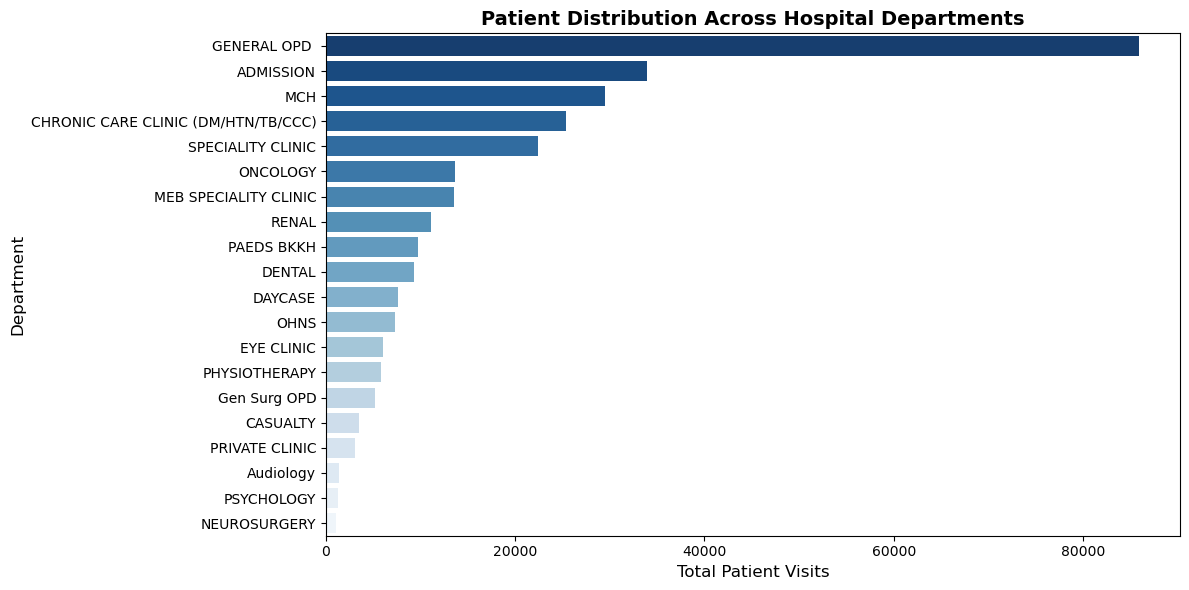

In [14]:
plt.figure(figsize=(12, 6))

# visits per department and sort descending for top 20
dept_counts = data["QueuedTo"].value_counts().head(20)

# horizontal bar plot
sns.barplot(x=dept_counts.values, y=dept_counts.index, palette="Blues_r")

plt.title("Patient Distribution Across Hospital Departments", fontsize=14, fontweight="bold")
plt.xlabel("Total Patient Visits", fontsize=12)
plt.ylabel("Department", fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
print(data['ConsultDescription'].unique())

['GEneral Outpatient Care( NEW )' nan 'General Outpatient Care'
 'Admission' 'EMERGENCY' 'CONSULT' 'RENAL DIALYSIS'
 'Child Welfare and Immunization (CWC)' 'MCH Clinic' 'Physiotherapy'
 'MCH (New Patient)' 'DAYCASE' 'Dental Care' 'ORTHOPEDIC' 'UROLOGY'
 'COUNSELLING PSYCHOLOGY' 'ENT First Visit' 'Chemotherapy'
 'GENERAL SURGERY' 'Ophthalmology.' 'ENT Return Visit' 'Pediatrics '
 'Comprehensive Care Centre (CCC)' 'Developmental Clinic '
 'Palliative Revisit' 'Diabetic clinic' 'Staff Clinic' 'ECHO'
 'Gen Surg OPD' 'PLASTICS' 'Cardiology' 'ONCOLOGY CONSULTATION' 'RVA'
 'GYNAECOLOGY' 'Nutrition Consult' 'OCCUPATIONAL THERAPY'
 'SPECIALITY IMED' 'BREAST' 'ANC Revisit' 'Family Planning'
 'Consultant Clinic' 'Paediatric Psychiatry' 'Psychiatry'
 'RENAL CONSULTATION' 'Oncology Service' 'Revisit' 'Counselling'
 'Hepatitis b vaccine' 'PEADS SURGE' 'Clinical psychology consultation'
 'TB CLINIC' 'Postnatal (PNC)' 'HAND CLINIC' 'HYPERTENSION CLINIC'
 'Gyn-oncology' 'Surgical OPD' 'TELEMEDICINE' 'E

In [16]:
#checking for missing values 
data.isna().sum()

PatientNumber            0
RegistrationDate         0
Gender                  15
Age                    571
QueuedTo              6778
ConsultDescription    6386
dtype: int64

In [17]:
missing = data.isnull().sum()
missing_percent = (missing/len(data)) * 100
pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

,Missing Count,Missing %
PatientNumber,0,0.000000
RegistrationDate,0,0.000000
Gender,15,0.004897
Age,571,0.186415
QueuedTo,6778,2.212820
ConsultDescription,6386,2.084843


Observation: There are missing values, however they make up a small percentage of the whole data so dropping them will not cause us to lose important insights of the data

In [18]:
#checking for duplicated values
data.duplicated().sum()

np.int64(355)

Observation: We will drop these duplicate values so that we ensure our model learns actual patterns and not repetative ones

In [19]:
#checking how many patients have visited hospital
print(data['PatientNumber'].nunique())
print(len(data))

80928
306306


observation: 80928 patients visited the hospital and the length of the data being larger indicated that there has been patients who have returned to the hospital

In [20]:
# example of return patients
visits = data['PatientNumber'].value_counts()
visits.head()

PatientNumber
010099285    266
010543010    252
010527584    249
010112639    248
010315077    247
Name: count, dtype: int64

In [23]:
# Minimum and maximum dates
dates = pd.to_datetime(data['RegistrationDate'], errors='coerce')
print(f'min: {dates.min()}')
print(f'max: {dates.max()}')

# Time destribution
dates.dt.hour.value_counts().sort_index()

min: 2024-06-01 00:00:00
max: 2026-08-19 11:41:53.073000


RegistrationDate
0     19821
1      1679
2      1042
3       958
4      1627
5      4440
6      9235
7     25081
8     55566
9     51435
10    35296
11    28743
12    20166
13    12185
14    10108
15     8478
16     6645
17     3637
18     2567
19     2085
20     1772
21     1542
22     1245
23      953
Name: count, dtype: int64

Text(0, 0.5, 'Number of patients')

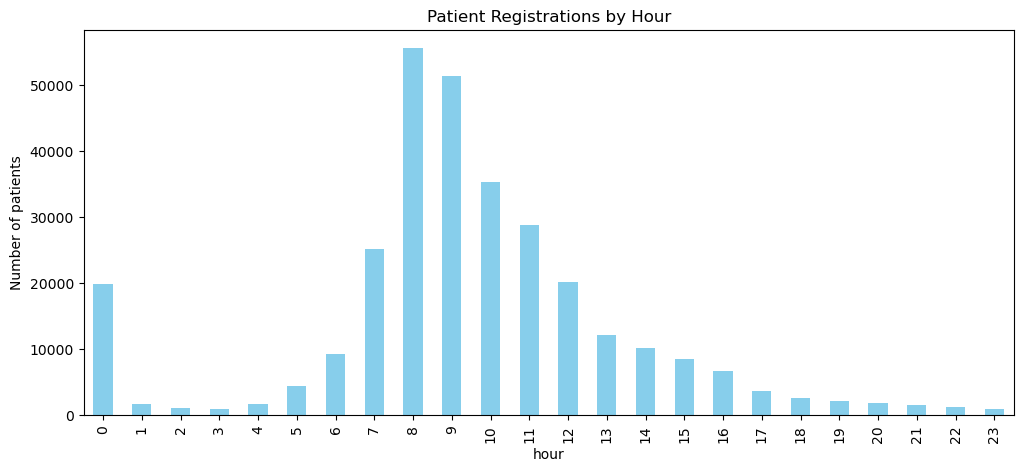

In [25]:
#visual
data["temp_datetime"] = dates
data["hour"] = dates.dt.hour

data["hour"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12,5),
    title="Patient Registrations by Hour",
    color='skyblue')
plt.ylabel('Number of patients')

Observation: The busiest hours of the day are usually within 07:00 and 14:00 having the high number of patients. From the time range 08:00 and 09:00 are the busiest

In [26]:
# daily visits
data['temp_datetime'].dt.day_name().value_counts()

temp_datetime
Monday       60299
Tuesday      59702
Thursday     59143
Wednesday    55624
Friday       52463
Saturday     11339
Sunday        7736
Name: count, dtype: int64

C:\Users\user\AppData\Local\Temp\ipykernel_19844\3884341220.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette="Blues_r")


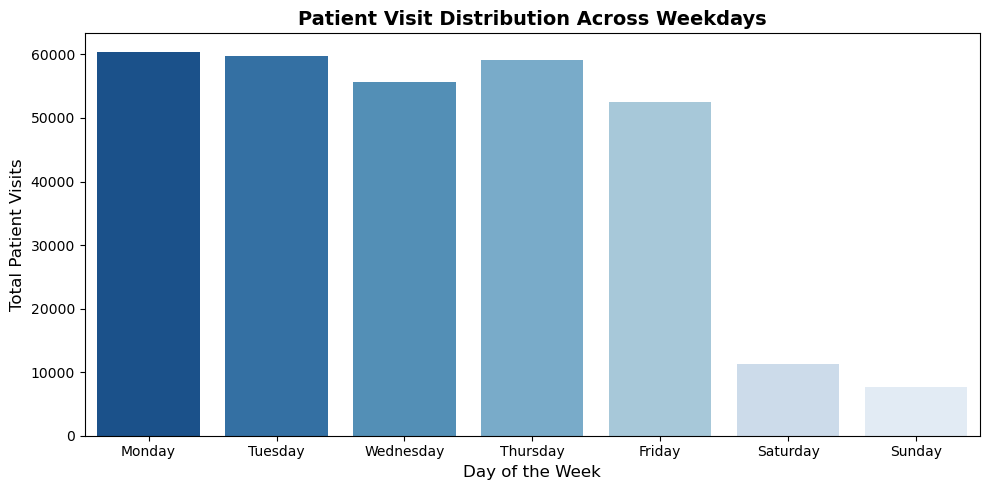

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
data["RegistrationDate"] = pd.to_datetime(data["RegistrationDate"], errors="coerce")
data["day_of_week"] = data["RegistrationDate"].dt.day_name()

# Define chronological weekday order
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday", 
    "Friday", "Saturday", "Sunday"
]

# Count visits per weekday and reindex
weekday_counts = data["day_of_week"].value_counts().reindex(weekday_order)

# Plot distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette="Blues_r")
plt.title("Patient Visit Distribution Across Weekdays", fontsize=14, fontweight="bold")
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Total Patient Visits", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Mid-Week Surge

Patient volume concentrates heavily during mid-week windows (typically Tuesday through Thursday), driven by scheduled outpatient clinics, specialist availability, and elective check-ins.

Weekend Drop-off

Volumes decline sharply over the weekend, reflecting reduced ambulatory service hours and limited elective scheduling, which leaves emergency and inpatient units handling the baseline load.

In [28]:
#Number of departmnets and how many visits
print(f'Number of departments:', data["QueuedTo"].nunique())
data['QueuedTo'].value_counts(dropna=False)

Number of departments: 44


QueuedTo
GENERAL OPD                            85959
ADMISSION                              33880
MCH                                    29467
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    25366
SPECIALITY CLINIC                      22356
ONCOLOGY                               13606
MEB SPECIALITY CLINIC                  13523
RENAL                                  11103
PAEDS BKKH                              9734
DENTAL                                  9252
DAYCASE                                 7596
OHNS                                    7290
NaN                                     6778
EYE CLINIC                              6027
PHYSIOTHERAPY                           5826
Gen Surg OPD                            5156
CASUALTY                                3460
PRIVATE CLINIC                          3075
Audiology                               1379
PSYCHOLOGY                              1223
NEUROSURGERY                            1032
OCCUPATIONAL THERAPY                     815
N

In [ ]:
# Visits per consultation type
data["ConsultDescription"].value_counts(dropna=False)

ConsultDescription
General Outpatient Care           49377
Admission                         33886
CONSULT                           33336
GEneral Outpatient Care( NEW )    21398
MCH Clinic                        19465
                                  ...  
PAIN CLINIC                           2
Head & Neck Return Visit              1
Staff Wellness Package                1
HEAD AND NECK VISIT                   1
Private Gyn Oncology                  1
Name: count, Length: 80, dtype: int64

Observation: Majority visits are:
- General Outpatient Care           
- Admission                         
- CONSULT 

In [50]:
#Distribution of gender
data["Gender"].value_counts(dropna=False)


Gender
Female    142251
Male      112802
FEMALE     32185
MALE       19053
NaN           15
Name: count, dtype: int64

Observation: Theres inconsistent formating which needs to be cleaned

In [51]:
#Age distribution
data["Age"].value_counts()

Age
2 Yr(s)      7464
31 Yr(s)     5741
30 Yr(s)     5533
29 Yr(s)     5418
33 Yr(s)     5255
             ... 
2 Days(s)       2
121 Yr(s)       1
107 Yr(s)       1
117 Yr(s)       1
3 Days(s)       1
Name: count, Length: 142, dtype: int64

Observation

1. Data description 
- What's in it: Patient ID, registration date/time, gender, age (written as text, like "38 Yr(s)"), which department the patient was sent to (44 possible departments), and the type of visit (79 possible types). Everything is text or dates no ready-made numbers or categories yet.
- Who the patients are: 80,928 different patients, visiting 3.8 times on average. About 57% are female, 43% male. Median age is 40. Most patients only come once (39%), but a small group (7.7%) comes 10+ times, likely people with ongoing conditions needing regular care.
- Departments: 7 out of 44 departments make up about 70% of all visits, General Outpatient, Admission, MCH, Chronic Care, Speciality Clinic, Oncology, and Renal. The rest get far fewer visits.
- Patterns over time: More patients come on weekdays than weekends, with Monday the busiest and weekends much quieter. Most patients arrive between 8-9am, then it tapers off through the day. The number of visits per month stays fairly steady (10,000–13,000), though the last month isn't fully counted yet.

2. Verify Data Quality

These are common problems in hospital records like this none of them are serious enough to stop the project, but they all need fixing before we build any models:

- Missing information: some rows are missing gender (15), age (571), department (6,778), or visit type (6,386). The missing department and visit type are the most important to fix, since they're central to what we're trying to study.
- 355 rows are exact copies of another row — probably accidental double entries.
- Gender is written inconsistently — sometimes "Male", sometimes "MALE".
- Visit types are written inconsistently too, with typos and different spellings for what should be the same thing (e.g. "General Outpatient Care" vs "GEneral Outpatient Care( NEW )"). We'll need to fix the typos but keep any real differences, like whether it's a new or returning patient.
- Age is written as text, not numbers, and mixes different units (years, months, weeks, days), so it needs to be converted before we can use it.
- A few ages are unrealistic (over 110 years old) — most likely mistakes.
- 3 rows list departments that don't make sense — they look like test entries, not real departments.
- 10,292 rows show an exact midnight timestamp, which is probably just a placeholder for "we don't know the exact time" rather than real midnight visits — so we should be careful using time-of-day data for these.

# Data Cleaning